<a href="https://colab.research.google.com/github/AmirNabiyev30/Elder_Fraud_Protection/blob/main/Elder_Fraud_Protection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kagglehub[pandas-datasets] --quiet

In [2]:
import kagglehub
import pandas as pd
import numpy as np
from google.colab import files
import os
import seaborn as sns
import matplotlib.pyplot as plt
from kagglehub import KaggleDatasetAdapter
import re
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
import nltk

In [3]:
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [5]:
files.upload()

KeyboardInterrupt: 

In [ ]:
os.makedirs("/root/.kaggle", exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
file_path='df.csv'
dataset_name = "akshatsharma2/the-biggest-spam-ham-phish-email-dataset-300000"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    dataset_name,
    file_path,
)

print("First 5 records:\n", df.head())

/tmp/ipykernel_714/3939100370.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 601M/601M [00:14<00:00, 44.7MB/s]


First 5 records:
    label                                               text
0      0  wrong bill grace i ' ll forward original messa...
1      0  i have continued the hilcorp old ocean deal da...
2      0  several related issues have resulted in an inc...
3      0  one year rate for this one will be escapenumbe...
4      0  attached is the weekly deal report for escapen...


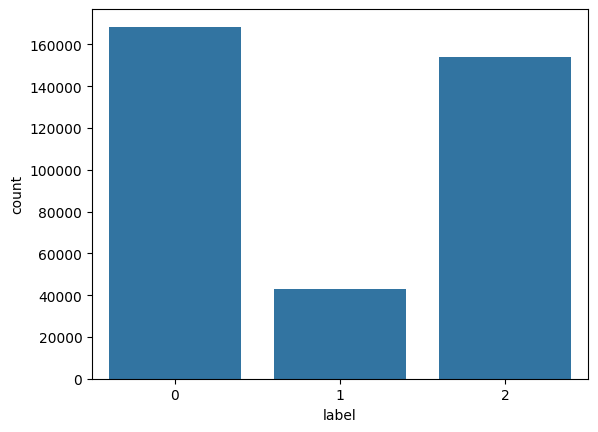

In [ ]:
sns.countplot(x='label',data=df)
plt.show()


In [ ]:
df.isnull().sum()

,0
label,0
text,2


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
label,0
text,0


In [ ]:
df_balanced = df.copy()
ham   = df_balanced[df_balanced['label'] == 0]
phish = df_balanced[df_balanced['label'] == 1]
spam  = df_balanced[df_balanced['label'] == 2]
TARGET = len(phish)

In [ ]:
from sklearn.utils import resample
ham_downsampled  = resample(ham,  replace=False, n_samples=TARGET, random_state=42)
spam_downsampled = resample(spam, replace=False, n_samples=TARGET, random_state=42)

In [ ]:
df_balanced = pd.concat([ham_downsampled, phish, spam_downsampled])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

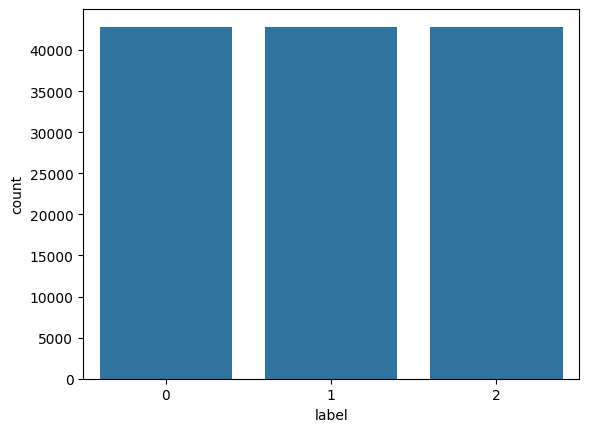

In [ ]:
sns.countplot(x='label',data=df_balanced)
plt.show()


In [ ]:
df_balanced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128535 entries, 0 to 128534
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   label   128535 non-null  int64 
 1   text    128535 non-null  object
dtypes: int64(1), object(1)
memory usage: 2.0+ MB


In [ ]:
def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
df_balanced["text"] = df_balanced["text"].apply(clean_text)

In [ ]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

In [ ]:
def stem(text):
  tokens = word_tokenize(text.lower())
  return ' '.join([stemmer.stem(t) for t in tokens])

def lem(text):
  tokens = word_tokenize(text.lower())
  return ' '.join([lemmatizer.lemmatize(t) for t in tokens])

In [ ]:
df_balanced['text_stemmed'] = df_balanced['text'].apply(stem)
df_balanced['text_lemmatized'] = df_balanced['text'].apply(lem)

In [ ]:
df_balanced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128535 entries, 0 to 128534
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   label            128535 non-null  int64 
 1   text             128535 non-null  object
 2   text_stemmed     128535 non-null  object
 3   text_lemmatized  128535 non-null  object
dtypes: int64(1), object(3)
memory usage: 3.9+ MB


In [ ]:
df_balanced.to_csv("/content/balanced_data.csv", index=False)

In [ ]:
df_balanced = pd.read_csv("/content/balanced_data.csv")

In [ ]:
df_balanced.head()

,Unnamed: 0,label,text,text_stemmed,text_lemmatized
0,0,0,dawn per ricks email below aleck submitted a v...,dawn per rick email below aleck submit a verba...,dawn per rick email below aleck submitted a ve...
1,1,1,copeland individuate paliourg going closing so...,copeland individu paliourg go close soon highe...,copeland individuate paliourg going closing so...
2,2,0,i think i can get jeff king done with a simple...,i think i can get jeff king done with a simpl ...,i think i can get jeff king done with a simple...
3,3,1,ashby onstad colamamshinetnet dear fcddfbaafb ...,ashbi onstad colamamshinetnet dear fcddfbaafb ...,ashby onstad colamamshinetnet dear fcddfbaafb ...
4,4,1,dalton avery josueevolvebarrygopsaratogaorg ge...,dalton averi josueevolvebarrygopsaratogaorg ge...,dalton avery josueevolvebarrygopsaratogaorg ge...


In [ ]:
df_balanced.isnull().sum()

,0
Unnamed: 0,0
label,0
text,2
text_stemmed,3
text_lemmatized,3


In [ ]:
df_balanced.dropna(inplace=True)

In [ ]:
df_balanced.isnull().sum()

,0
Unnamed: 0,0
label,0
text,0
text_stemmed,0
text_lemmatized,0


In [ ]:
res = {}

vectorizer = TfidfVectorizer()

text_variants = {"raw": df_balanced["text"],
                 "stem" : df_balanced["text_stemmed"],
                 "lemm" : df_balanced["text_lemmatized"]}

for name,variant in text_variants.items():
  # Fill NaN values with empty strings before vectorizing to prevent ValueError
  X = vectorizer.fit_transform(variant.fillna(''))
  y = df_balanced["label"]

  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
  model = LogisticRegression()
  model.fit(X_train, y_train)

  acc = model.score(X_test, y_test)
  res[name] = acc


In [ ]:
for name,acc in res.items():
  print(name, ": ", acc)


raw :  0.9223454833597464
stem :  0.9260433174854728
lemm :  0.9255150554675119


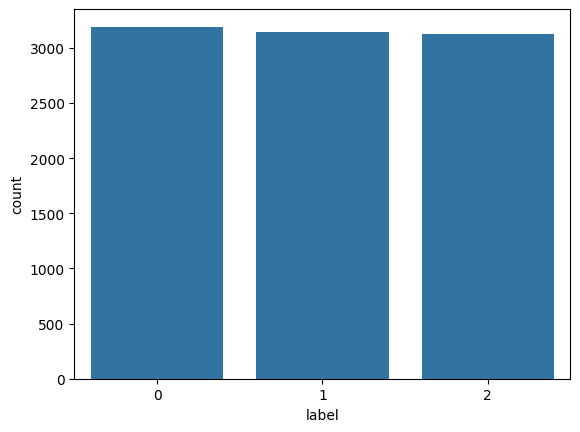

In [ ]:
sns.countplot(x='label',data=df_balanced)
plt.show()